In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 设置中文字体为宋体或黑体
plt.rcParams["font.sans-serif"] = ["SimSong", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_classes=2,
    random_state=42,
    n_clusters_per_class=1,
)

[Text(0.5, 1.0, 'Original Data'),
 Text(0.5, 0, 'Feature 1'),
 Text(0, 0.5, 'Feature 2'),
 None]

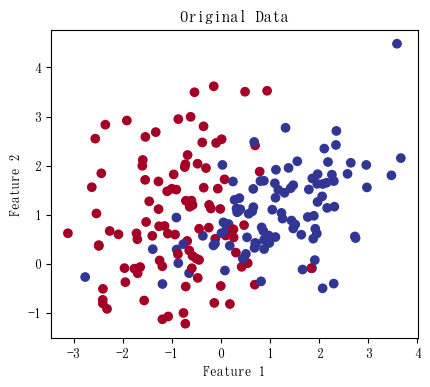

In [3]:
_, ax = plt.subplots(figsize=(8, 4))

ax.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap=plt.cm.RdYlBu,
)
ax.set(title="Original Data", xlabel="Feature 1", ylabel="Feature 2", aspect="equal")

## 数据标准化

In [4]:
features = pd.DataFrame(X, columns=["feature_1", "feature_2"])
target = pd.Series(y, name="target")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled = pd.DataFrame(X_scaled, columns=features.columns)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, target, test_size=0.3, random_state=42
)
print(f"训练集样本数: {len(y_train)}")
print(f"测试集样本数: {len(y_test)}")

训练集样本数: 140
测试集样本数: 60


## 线性可分SVM


Text(0.5, 0.98, 'Linear SVM with Different C Values')

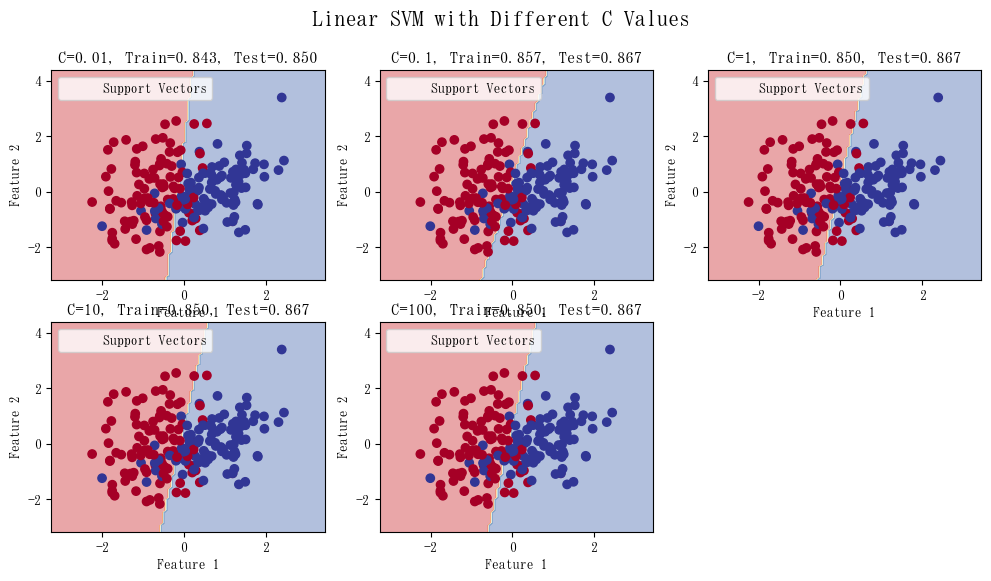

In [6]:
C_values = [0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for C, ax in zip(C_values, axes.flatten()):
    model = SVC(kernel="linear", C=C)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_scaled,
        ax=ax,
        alpha=0.4,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
    )
    ax.scatter(
        X_train.iloc[:, 0],
        X_train.iloc[:, 1],
        c=y_train,
        cmap=plt.cm.RdYlBu,
    )
    ax.scatter(
        X_test.iloc[:, 0],
        X_test.iloc[:, 1],
        c=y_test,
        cmap=plt.cm.RdYlBu,
    )
    ax.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        facecolors="none",
        label="Support Vectors",
    )
    ax.set(
        title=f"C={C}, Train={train_acc:.3f}, Test={test_acc:.3f}",
        xlabel="Feature 1",
        ylabel="Feature 2",
    )
    ax.legend()

axes[-1, -1].set(visible=False)
plt.suptitle("Linear SVM with Different C Values", fontsize=16)

## 核函数对比

In [7]:
model_linear = SVC(kernel="linear", C=1.0)
model_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")

model_linear.fit(X_train, y_train)
model_rbf.fit(X_train, y_train)

acc_linear = accuracy_score(y_test, model_linear.predict(X_test))
acc_rbf = accuracy_score(y_test, model_rbf.predict(X_test))

print(f"线性核测试准确率: {acc_linear:.4f}")
print(f"RBF核测试准确率: {acc_rbf:.4f}")

线性核测试准确率: 0.8667
RBF核测试准确率: 0.8500


Text(0.5, 0.98, 'Linear vs RBF Kernel SVM')

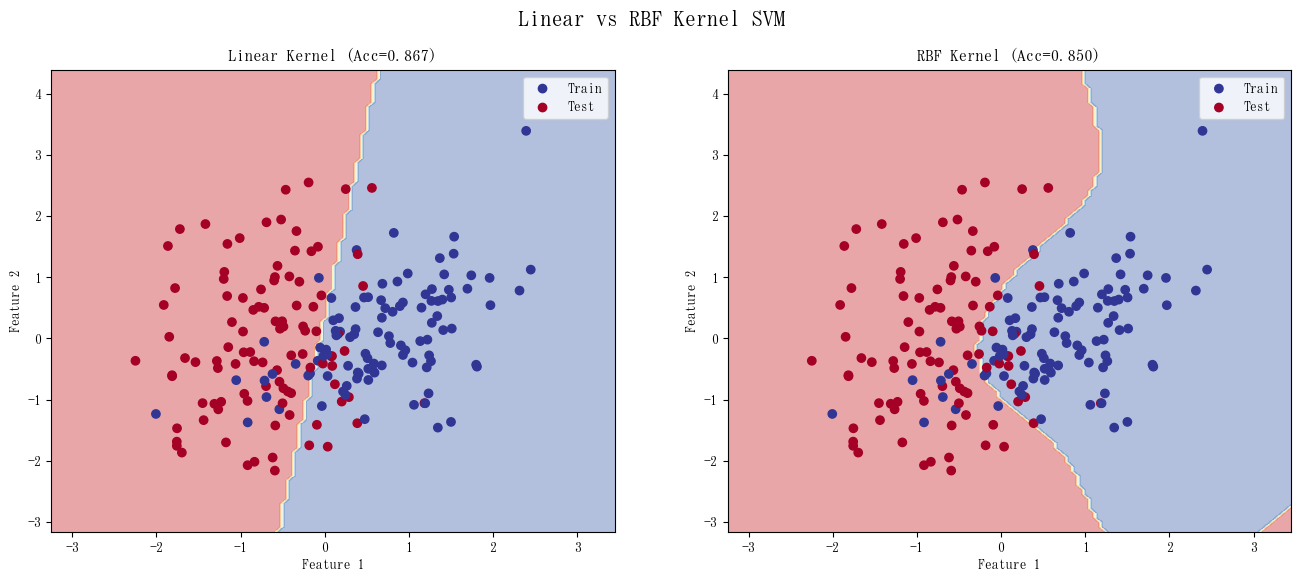

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
DecisionBoundaryDisplay.from_estimator(
    model_linear,
    X_scaled,
    ax=axes[0],
    alpha=0.4,
    cmap=plt.cm.RdYlBu,
    response_method="predict",
)
axes[0].scatter(
    X_train.iloc[:, 0],
    X_train.iloc[:, 1],
    c=y_train,
    cmap=plt.cm.RdYlBu,
    label="Train",
)
axes[0].scatter(
    X_test.iloc[:, 0],
    X_test.iloc[:, 1],
    c=y_test,
    cmap=plt.cm.RdYlBu,
    label="Test",
)
axes[0].set(
    title=f"Linear Kernel (Acc={acc_linear:.3f})",
    xlabel="Feature 1",
    ylabel="Feature 2",
)
axes[0].legend()
DecisionBoundaryDisplay.from_estimator(
    model_rbf,
    X_scaled,
    ax=axes[1],
    alpha=0.4,
    cmap=plt.cm.RdYlBu,
    response_method="predict",
)
axes[1].scatter(
    X_train.iloc[:, 0],
    X_train.iloc[:, 1],
    c=y_train,
    cmap=plt.cm.RdYlBu,
    label="Train",
)
axes[1].scatter(
    X_test.iloc[:, 0],
    X_test.iloc[:, 1],
    c=y_test,
    cmap=plt.cm.RdYlBu,
    label="Test",
)
axes[1].set(
    title=f"RBF Kernel (Acc={acc_rbf:.3f})", xlabel="Feature 1", ylabel="Feature 2"
)
axes[1].legend()
plt.suptitle("Linear vs RBF Kernel SVM", fontsize=16)

## gamma参数


Text(0.5, 0.98, 'RBF SVM with Different Gamma Values')

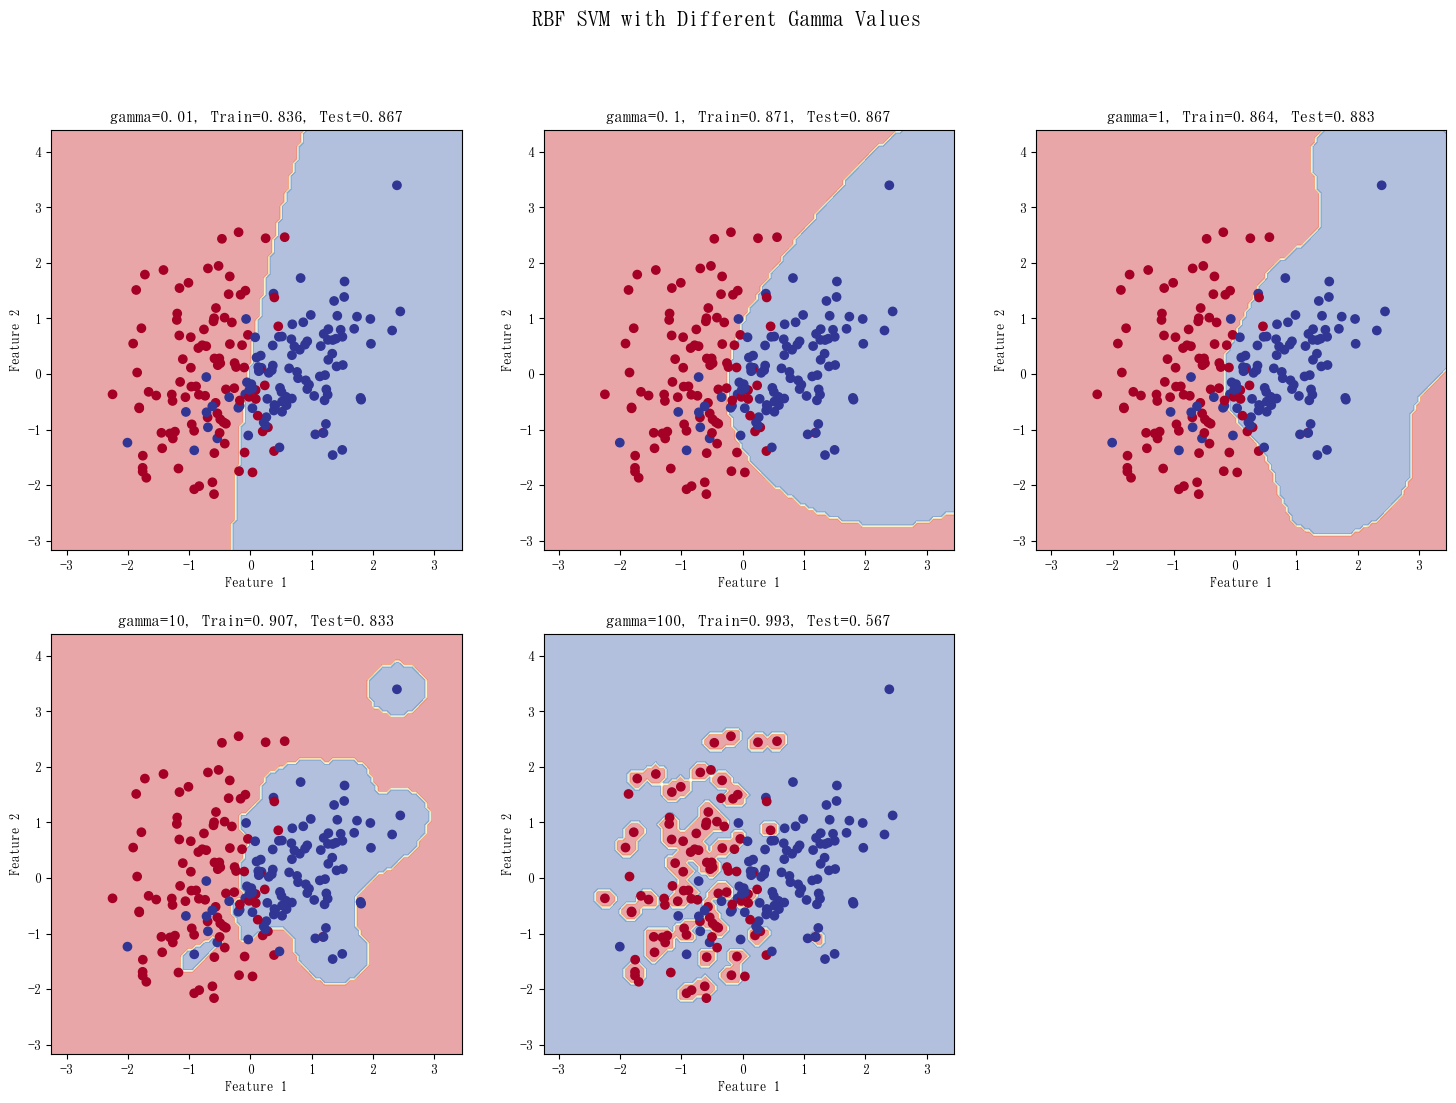

In [9]:
gammas = [0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for gamma, ax in zip(gammas, axes.flatten()):
    model = SVC(kernel="rbf", C=1.0, gamma=gamma)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    DecisionBoundaryDisplay.from_estimator(
        model,
        X_scaled,
        ax=ax,
        alpha=0.4,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
    )
    ax.scatter(
        X_train.iloc[:, 0],
        X_train.iloc[:, 1],
        c=y_train,
        cmap=plt.cm.RdYlBu,
    )
    ax.scatter(
        X_test.iloc[:, 0],
        X_test.iloc[:, 1],
        c=y_test,
        cmap=plt.cm.RdYlBu,
    )
    ax.set(
        title=f"gamma={gamma}, Train={train_acc:.3f}, Test={test_acc:.3f}",
        xlabel="Feature 1",
        ylabel="Feature 2",
    )

axes[-1, -1].set(visible=False)
plt.suptitle("RBF SVM with Different Gamma Values", fontsize=16)

## 网格搜索

In [10]:
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["linear", "rbf"],
}
model = SVC()
grid_search = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证分数: {grid_search.best_score_:.4f}")


最佳参数: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
最佳交叉验证分数: 0.8643


In [11]:
cv_results = grid_search.cv_results_
results_df = pd.DataFrame(
    {
        "C": cv_results["param_C"],
        "gamma": cv_results["param_gamma"],
        "kernel": cv_results["param_kernel"],
        "mean_test_score": cv_results["mean_test_score"],
    }
)
pivot_table = results_df.pivot_table(
    index="kernel", columns="C", values="mean_test_score"
)
pivot_table

C,0.1,1.0,10.0
kernel,,,
linear,0.842857,0.857143,0.850000
rbf,0.771429,0.850000,0.853571


## 不平衡数据

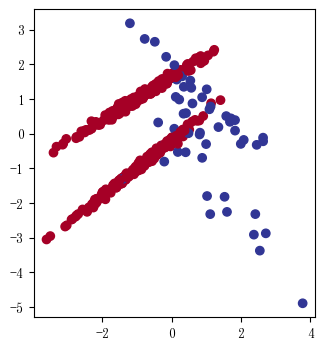

In [12]:
# Number of informative, redundant and repeated features must sum to less than the number of total features
X_imb, y_imb = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_repeated=0,
    n_classes=2,
    weights=[0.9, 0.1],
    random_state=42,
)

_, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_imb[:, 0], X_imb[:, 1], c=y_imb, cmap=plt.cm.RdYlBu)
ax.set(aspect="equal");

In [13]:
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)
print(f"训练集类别分布: {np.bincount(y_imb_train)}")
print(f"测试集类别分布: {np.bincount(y_imb_test)}")

训练集类别分布: [313  37]
测试集类别分布: [134  16]


In [14]:
model_balanced = SVC(kernel="rbf", class_weight="balanced", probability=True)
model_balanced.fit(X_imb_train, y_imb_train)
y_prob_balanced = model_balanced.predict_proba(X_imb_test)[:, 1]
auc_balanced = roc_auc_score(y_imb_test, y_prob_balanced)
print(f"类别权重法 AUC: {auc_balanced:.4f}")

类别权重法 AUC: 0.9016


In [15]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imb_train, y_imb_train)
print(f"过采样后训练集类别分布: {np.bincount(y_resampled)}")

过采样后训练集类别分布: [313 313]


In [16]:
model_smote = SVC(kernel="rbf", probability=True)
model_smote.fit(X_resampled, y_resampled)
y_prob_smote = model_smote.predict_proba(X_imb_test)[:, 1]
auc_smote = roc_auc_score(y_imb_test, y_prob_smote)
print(f"SMOTE过采样法 AUC: {auc_smote:.4f}")
print("\n方法对比:")
print(f"类别权重法 AUC: {auc_balanced:.4f}")
print(f"SMOTE过采样法 AUC: {auc_smote:.4f}")

SMOTE过采样法 AUC: 0.9035

方法对比:
类别权重法 AUC: 0.9016
SMOTE过采样法 AUC: 0.9035


## 多分类策略


In [17]:
X_multi, y_multi = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_classes=3,
    random_state=42,
    n_clusters_per_class=1,
)
X_multi_scaled = StandardScaler().fit_transform(X_multi)
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi_scaled, y_multi, test_size=0.3, random_state=42, stratify=y_multi
)
print(f"训练集类别分布: {np.bincount(y_multi_train)}")
print(f"测试集类别分布: {np.bincount(y_multi_test)}")

训练集类别分布: [70 70 70]
测试集类别分布: [30 30 30]


In [18]:
start_time = time.time()
model_ovr = OneVsRestClassifier(SVC(kernel="linear", probability=True))
model_ovr.fit(X_multi_train, y_multi_train)
ovr_time = time.time() - start_time
ovr_acc = accuracy_score(y_multi_test, model_ovr.predict(X_multi_test))
print(f"OvR 训练时间: {ovr_time:.4f} 秒")
print(f"OvR 测试准确率: {ovr_acc:.4f}")

OvR 训练时间: 0.0101 秒
OvR 测试准确率: 0.9000


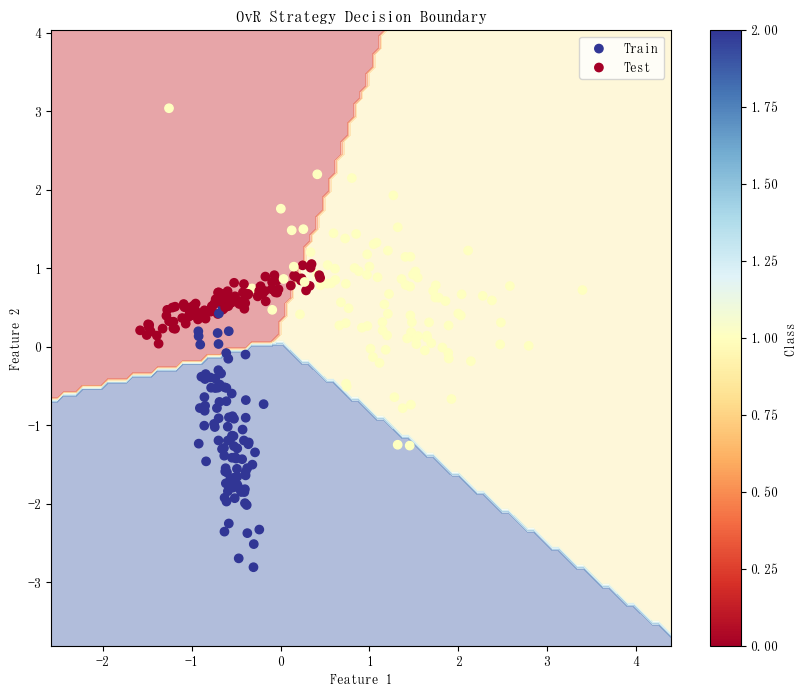

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
DecisionBoundaryDisplay.from_estimator(
    model_ovr,
    X_multi_scaled,
    ax=ax,
    alpha=0.4,
    cmap=plt.cm.RdYlBu,
    response_method="predict",
)
scatter = ax.scatter(
    X_multi_train[:, 0],
    X_multi_train[:, 1],
    c=y_multi_train,
    cmap=plt.cm.RdYlBu,
    label="Train",
)
ax.scatter(
    X_multi_test[:, 0],
    X_multi_test[:, 1],
    c=y_multi_test,
    cmap=plt.cm.RdYlBu,
    label="Test",
)
ax.set(title="OvR Strategy Decision Boundary", xlabel="Feature 1", ylabel="Feature 2")
ax.legend()
plt.colorbar(scatter, ax=ax, label="Class")

In [20]:
start_time = time.time()
model_ovo = OneVsOneClassifier(SVC(kernel="linear", probability=True))
model_ovo.fit(X_multi_train, y_multi_train)
ovo_time = time.time() - start_time
ovo_acc = accuracy_score(y_multi_test, model_ovo.predict(X_multi_test))
print(f"OvO 训练时间: {ovo_time:.4f} 秒")
print(f"OvO 测试准确率: {ovo_acc:.4f}")

OvO 训练时间: 0.0508 秒
OvO 测试准确率: 0.9444



多分类策略对比:
OvR 训练时间: 0.0101 秒, 准确率: 0.9000
OvO 训练时间: 0.0508 秒, 准确率: 0.9444


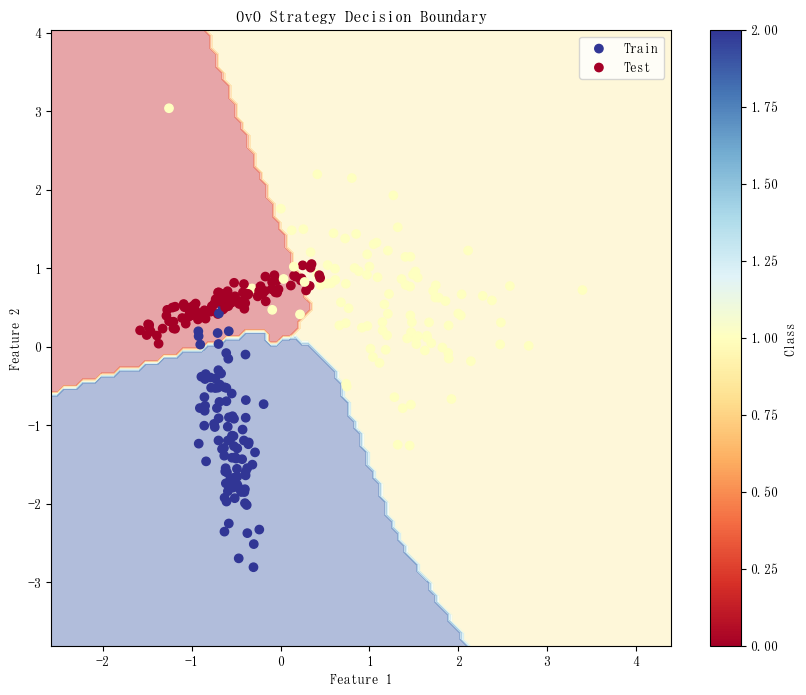

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
DecisionBoundaryDisplay.from_estimator(
    model_ovo,
    X_multi_scaled,
    ax=ax,
    alpha=0.4,
    cmap=plt.cm.RdYlBu,
    response_method="predict",
)
scatter = ax.scatter(
    X_multi_train[:, 0],
    X_multi_train[:, 1],
    c=y_multi_train,
    cmap=plt.cm.RdYlBu,
    label="Train",
)
ax.scatter(
    X_multi_test[:, 0],
    X_multi_test[:, 1],
    c=y_multi_test,
    cmap=plt.cm.RdYlBu,
    label="Test",
)
ax.set(title="OvO Strategy Decision Boundary", xlabel="Feature 1", ylabel="Feature 2")
ax.legend()
plt.colorbar(scatter, ax=ax, label="Class")
()
print("\n多分类策略对比:")
print(f"OvR 训练时间: {ovr_time:.4f} 秒, 准确率: {ovr_acc:.4f}")
print(f"OvO 训练时间: {ovo_time:.4f} 秒, 准确率: {ovo_acc:.4f}")